## Rozdelenie dát

Súbor: rozdelenie_dat.ipynb

Program: Hospodárska informatika

Vypracovala: Bc. Terézia Drengubiaková

Bakalárska práca: : Metódy strojového učenia pre včasnú predikciu geomagnetických búrok

Vedúci diplomovej práce: doc. Ing. Peter Butka, PhD.

Konzultanti: Ing. Viera Krešňáková, PhD., RNDr. Šimon Mackovjak, PhD.

### Import knižníc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
%matplotlib inline
register_matplotlib_converters()

### Načítanie upraveného datasetu

In [2]:
df = pd.read_csv('allDST_omni.csv')

### Úprava atribútu time1 na datetime

In [3]:
df['time1'] = pd.to_datetime(df['time1'])

### Výber dátumu pre rozdelenie dát na trénovaciu a testovaciu časť

In [4]:
split_index = df[df['time1'] >= '2003-11-19'].index.min()

### Rozdelenie

In [5]:
train = df.iloc[:split_index, :]
test = df.iloc[split_index:, :]

### Kontrola konca trénovacieho datasetu

In [6]:
train.tail()

,Unnamed: 0,time1,bz_gsm,v,DST,DST+1,DST+2,DST+3,DST+4,DST+5,DST+6
358363,358363,2003-11-18 19:30:00+00:00,0.2,691.0,-22,-22,-20.0,-16.0,-15.0,-17.0,-15.0
358364,358364,2003-11-18 20:30:00+00:00,-0.2,684.0,-20,-20,-16.0,-15.0,-17.0,-15.0,-18.0
358365,358365,2003-11-18 21:30:00+00:00,1.9,669.0,-16,-16,-15.0,-17.0,-15.0,-18.0,-18.0
358366,358366,2003-11-18 22:30:00+00:00,-0.2,646.0,-15,-15,-17.0,-15.0,-18.0,-18.0,-18.0
358367,358367,2003-11-18 23:30:00+00:00,-0.8,644.0,-17,-17,-15.0,-18.0,-18.0,-18.0,-22.0


### Výber potrebných atribútov pre testovací dataset

In [7]:
test = test[["time1", "bz_gsm", "v", "DST", "DST+1", "DST+2", "DST+3", "DST+4", "DST+5", "DST+6"]]

### Kontrola testovacieho datasetu

In [8]:
test.head()

,time1,bz_gsm,v,DST,DST+1,DST+2,DST+3,DST+4,DST+5,DST+6
358368,2003-11-19 00:30:00+00:00,0.6,629.0,-15,-15,-18.0,-18.0,-18.0,-22.0,-27.0
358369,2003-11-19 01:30:00+00:00,0.2,629.0,-18,-18,-18.0,-18.0,-22.0,-27.0,-26.0
358370,2003-11-19 02:30:00+00:00,0.2,599.0,-18,-18,-18.0,-22.0,-27.0,-26.0,-26.0
358371,2003-11-19 03:30:00+00:00,0.3,587.0,-18,-18,-22.0,-27.0,-26.0,-26.0,-25.0
358372,2003-11-19 04:30:00+00:00,-1.2,588.0,-22,-22,-27.0,-26.0,-26.0,-25.0,-21.0


### Kontrola dĺžky datasetov

In [9]:
print(len(test))
print(len(train))

194200
358368


### Vytvorenie validačnej sady a vyobrazenie 

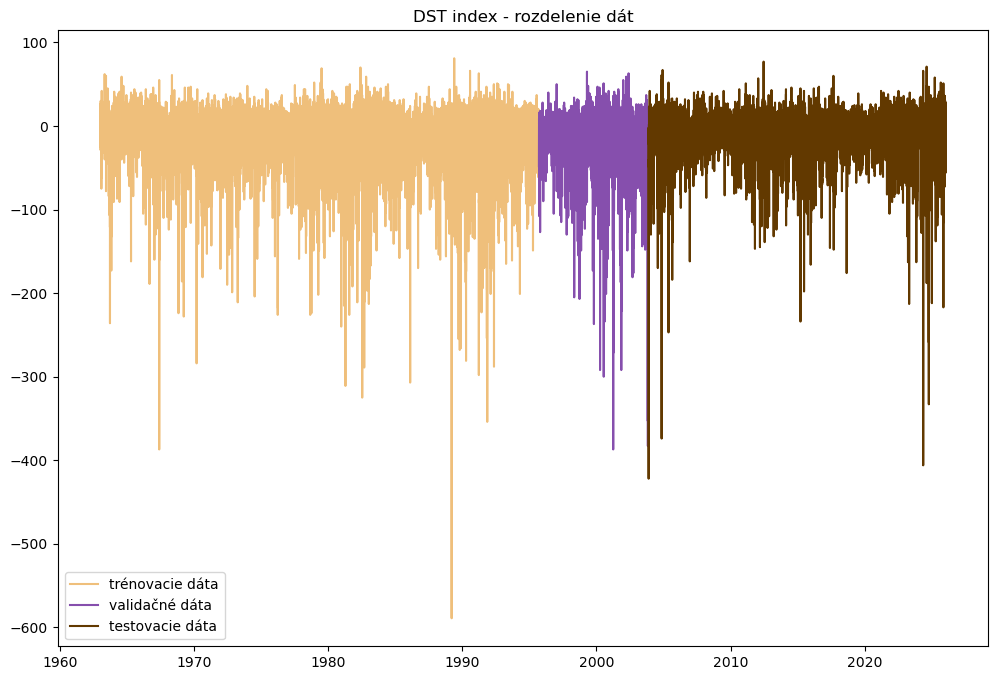

In [10]:
valid_size = int(len(train) * 0.2)
valid = train.iloc[-valid_size:,:].copy()
train = train.iloc[:-valid_size,:].copy()

plt.rcParams['figure.figsize'] = [12, 8]
plt.figure()
plt.title("DST index - rozdelenie dát")
plt.plot(train['time1'],train['DST'],label='trénovacie dáta', color="#EFBF7B")
plt.plot(valid['time1'],valid['DST'],label='validačné dáta', color="#864FAD")
plt.plot(test['time1'],test['DST'],label='testovacie dáta', color="#623900")
plt.savefig("dataset_cut.png")
plt.legend();

### Uloženie trénovacej a testovacej sady

In [11]:
test.to_csv('test_omni.csv')
train.to_csv('train_omni.csv')